# Estimating PSDs

This notebook should be run to get estimated PSDs from the LDC sangria dataset, as well as saving/smoothing the sangria noise model which contains ubnresolvable galactic binaries

In [1]:
import numpy as np
from copy import deepcopy

from pycbc.types import TimeSeries, FrequencySeries
from pycbc.psd import interpolate

import ldc.io.hdf5 as hdfio
import ldc.lisa.noise.noise as ldc_noise

from scipy.signal import windows

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
# This cell contains the information about certain input parameters which are 

paper_plot_dir = "../paper/images/dataset/"
input_data = '../datasets/LDC2_sangria_hm_training.hdf' # The Sangria dataset
output_format = '{channel}_sangria_hm_PSD.txt' # This is the format used for saving the datasets for estimated, not smoothed, PSDs
smoothed_output_format = '{channel}_sangria_hm_SMOOTHED_PSD.txt' # This is the format used for saving the datasets for estimated, smoothed, PSDs
segment_duration = 1576800 # Used in the PSD estimation
delta_t = 5. # Sampling rate of the Sangria dataset (s)

In [3]:
# Load in the sangria dataset

tdi_ts, tdi_descr = hdfio.load_array(input_data, name="obs/tdi")
X = tdi_ts['X']
Y = tdi_ts['Y']
Z = tdi_ts['Z']

In [4]:
# Convert to AET timeseries
A = (Z - X)/np.sqrt(2)
E = (X - 2*Y + Z)/np.sqrt(6)
T = (X + Y + Z)/np.sqrt(3)

A_ts = TimeSeries(A, delta_t=delta_t)
E_ts = TimeSeries(E, delta_t=delta_t)
T_ts = TimeSeries(T, delta_t=delta_t)

In [5]:
# Calculate the PSDs

A_psd = A_ts.psd(segment_duration)
E_psd = E_ts.psd(segment_duration)
T_psd = T_ts.psd(segment_duration)

# Interpolate onto a grid
A_psd = interpolate(A_psd, A_ts.delta_f)
E_psd = interpolate(E_psd, E_ts.delta_f)
T_psd = interpolate(T_psd, T_ts.delta_f)

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU response available.
No CuPy or GPU interpolation available.


In [6]:
# Save to files for use in later analysis

A_psd.save(output_format.format(channel='A'))
E_psd.save(output_format.format(channel='E'))
T_psd.save(output_format.format(channel='T'))

Now lets go through and remove all signals from the data, this will give us an estimate of the noise which we can compare to the model we used in the zero latency filter paper

In [7]:
residual_A = deepcopy(A_ts)
residual_E = deepcopy(E_ts)

signal_types = ['mbhb', 'vgb', 'dgb', 'igb']

for signal_type in signal_types:
    tdi_ts, tdi_descr = hdfio.load_array(input_data, name=f'/sky/{signal_type}/tdi')
    X = tdi_ts['X']
    Y = tdi_ts['Y']
    Z = tdi_ts['Z']

    A_sig = (Z - X)/np.sqrt(2)
    E_sig = (X - 2*Y + Z)/np.sqrt(6)

    residual_A.data -= A_sig
    residual_E.data -= E_sig

residual_A_psd = residual_A.psd(segment_duration)
residual_E_psd = residual_E.psd(segment_duration)

# Interpolate onto a grid
residual_A_psd = interpolate(residual_A_psd, A_ts.delta_f)
residual_E_psd = interpolate(residual_E_psd, E_ts.delta_f)

Lets compare this to the modelled PSD


In [8]:
# This is the model that was used for sangria which includes the unresolvable galactic binaries
sangria_model_freqs = A_psd.sample_frequencies

nm_withgb = ldc_noise.get_noise_model("sangria", sangria_model_freqs, wd=True)
sangria_model_ae_withgb = nm_withgb.psd(option="A")
sangria_model_t_withgb = nm_withgb.psd(option="T")

# Now lets _also_ get the PSD model which doesnt include GBs - this matches the one used in the zero latency filter paper
nm_nogb = ldc_noise.get_noise_model("sangria", sangria_model_freqs, wd=False)
sangria_model_ae_nogb = nm_nogb.psd(option="A")
sangria_model_t_nogb = nm_nogb.psd(option="T")

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:435: RuntimeWarning: divide by zero encountered in power
  return self._data ** other
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:348: RuntimeWarning: invalid value encountered in multiply
  return self._data * other


Lets quickly plot these so we can see what is happening:

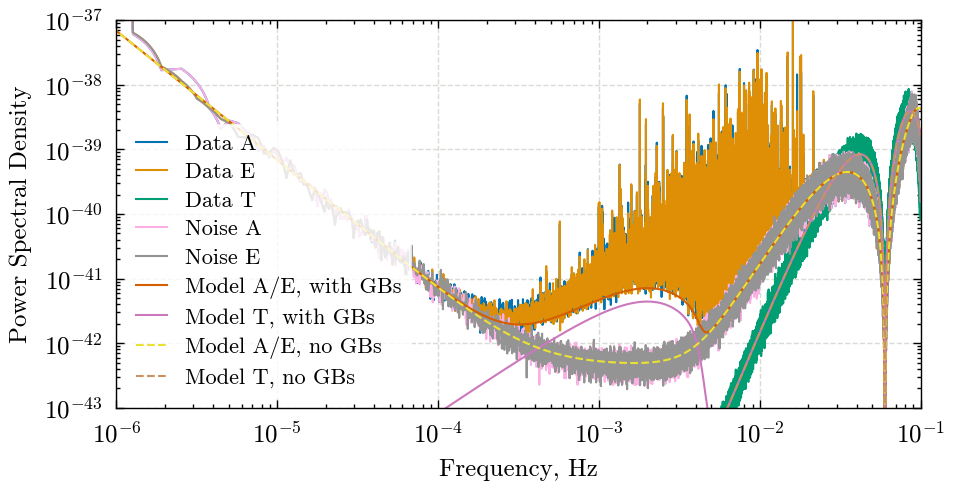

In [9]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))

ax.loglog(
    A_psd.sample_frequencies,
    A_psd,
    label='Data A',
    color=cycle[0]
)
ax.loglog(
    E_psd.sample_frequencies,
    E_psd,
    label='Data E',
    color=cycle[1]
)
ax.loglog(
    T_psd.sample_frequencies,
    T_psd,
    label='Data T',
    color=cycle[2]
)
ax.loglog(
    A_psd.sample_frequencies,
    residual_A_psd,
    label='Noise A',
    color=cycle[6]
)
ax.loglog(
    E_psd.sample_frequencies,
    residual_E_psd,
    label='Noise E',
    color=cycle[7]
)
ax.loglog(
    sangria_model_freqs,
    sangria_model_ae_withgb,
    label='Model A/E, with GBs',
    color=cycle[3]
)
ax.loglog(
    sangria_model_freqs,
    sangria_model_t_withgb,
    label='Model T, with GBs',
    color=cycle[4]
)
ax.loglog(
    sangria_model_freqs,
    sangria_model_ae_nogb,
    label='Model A/E, no GBs',
    linestyle='--',
    color=cycle[8]
)
ax.loglog(
    sangria_model_freqs,
    sangria_model_t_nogb,
    label='Model T, no GBs ',
    linestyle='--',
    color=cycle[5]
)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='lower left')
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)

Now, lets smooth out the dip at 0.06Hz. We want to do this for multiple cases, so lets define a function which smooths out the section between two frequencies

We will apply a window to the PSD, and the opposite window to a straight line between two points, the "smoothed" PSD will be the combination of the two

The line will be defined using the model PSD, so that it doesn't wiggle too much. So lets find the peaks either side, so that we can 'bridge the gap'

[1102984 3067167]
0.034975393201420596 0.09725922754946727


(0.03, 0.12)

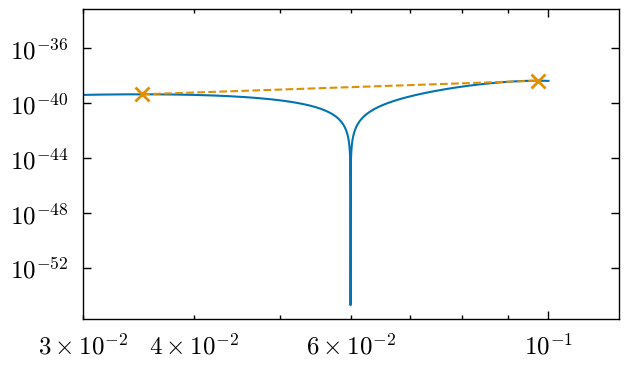

In [10]:
from scipy.signal import find_peaks

pks = find_peaks(
    np.where(
        np.logical_and(
            sangria_model_freqs > 0.01,
            sangria_model_freqs < 0.1
        ),
        sangria_model_ae_withgb,
        0
    )
)[0]
print(pks)

section_lower, section_upper = sangria_model_freqs[pks]
print(section_lower, section_upper)

plt.loglog(sangria_model_freqs, sangria_model_ae_withgb)
plt.plot(sangria_model_freqs[pks], sangria_model_ae_withgb[pks], linestyle='--', marker='x')
plt.xlim(0.03, 0.12)

In [11]:
def smooth_section(psd_freqseries, start_frequency, end_frequency, psd_model, psd_model_frequencies, psd_frequencies=False):

    # We are going to get the "smoothing line" from the model, so that it
    # isn't affected by the noise in the estimated PSD

    model_section = np.logical_and(
        psd_model_frequencies >= start_frequency,
        psd_model_frequencies <= end_frequency
    )

    model_freqs = psd_model_frequencies[model_section]
    model_y = psd_model[model_section]

    start_x = model_freqs[0]
    start_y = model_y[0]
    end_x = model_freqs[-1]
    end_y = model_y[-1]

    slope = (np.log(end_y) - np.log(start_y)) / (np.log(end_x) - np.log(start_x))
    intercept = np.log(start_y) - slope * np.log(start_x)

    if isinstance(psd_freqseries, FrequencySeries) and psd_frequencies is not False:
        raise ValueError('Do not provide psd_frequencies if psd_freqseries is a FrequencySeries')
    elif isinstance(psd_freqseries, FrequencySeries):
        psd_frequencies = psd_freqseries.sample_frequencies

    smoothed_section_psd = np.logical_and(
        psd_frequencies >= start_frequency,
        psd_frequencies <= end_frequency
    )
    smoothed_freqs = psd_frequencies[smoothed_section_psd]
    smoothed_y = psd_freqseries[smoothed_section_psd]

    # Get the line at the frequencies in the PSD
    line_out = np.exp(intercept) * (smoothed_freqs ** slope)

    # use a window function to combine the line and the PSD
    N = smoothed_freqs.size
    window = windows.hann(N)
    windowed_line = line_out * window
    windowed_psd = smoothed_y * (1-window)
    fuzzy_line = windowed_line + windowed_psd
    psd_out = deepcopy(psd_freqseries.data)
    psd_out[smoothed_section_psd] = fuzzy_line

    return psd_out, fuzzy_line, line_out

In [12]:
smoothed_section = np.logical_and(A_psd.sample_frequencies >= section_lower, A_psd.sample_frequencies <= section_upper)

# We don't want to introduce a discontinuity here though!
# First, lets find the straight line (log-log space) which goes from the first removed datapoint to the last
smoothed_freqs = A_psd.sample_frequencies[smoothed_section]

In [13]:
A_psd_smoothed, fuzzy_line_A, model_line = smooth_section(A_psd, section_lower, section_upper, sangria_model_ae_withgb, sangria_model_freqs)
E_psd_smoothed, fuzzy_line_E, _ = smooth_section(E_psd, section_lower, section_upper, sangria_model_ae_withgb, sangria_model_freqs)
modelled_psd_smoothed, _, _ = smooth_section(sangria_model_ae_withgb, section_lower, section_upper, sangria_model_ae_withgb, sangria_model_freqs, psd_frequencies=sangria_model_freqs)

Save the PSDs for later use

In [14]:
# Remove nans:
A_psd_smoothed[0] = 0
E_psd_smoothed[0] = 0
modelled_psd_smoothed[0] = 0
sangria_model_ae_withgb[0] = 0
sangria_model_t_withgb[0] = 0

np.savetxt(
    'A_sangria_hm_SMOOTHED_PSD.txt',
    np.array([
        sangria_model_freqs,
        A_psd_smoothed
    ]).T
)
np.savetxt(
    'E_sangria_hm_SMOOTHED_PSD.txt',
    np.array([
        sangria_model_freqs,
        E_psd_smoothed
    ]).T
)
np.savetxt(
    'model_AE_SMOOTHED_PSD.txt',
    np.array([
        sangria_model_freqs,
        modelled_psd_smoothed
    ]).T
)
np.savetxt(
    'model_AE_PSD.txt',
    np.array([
        sangria_model_freqs,
        sangria_model_ae_withgb
    ]).T
)
np.savetxt(
    'model_T_PSD.txt',
    np.array([
        sangria_model_freqs,
        sangria_model_t_withgb
    ]).T
)

Zoom in and see what is happening

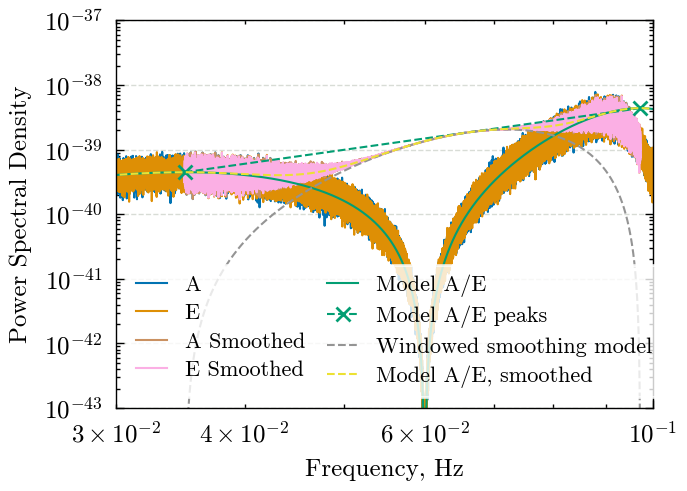

In [15]:

width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))

ax.loglog(
    A_psd.sample_frequencies,
    A_psd,
    label='A',
    color=cycle[0]
)
ax.loglog(
    E_psd.sample_frequencies,
    E_psd,
    label='E',
    color=cycle[1]
)
ax.loglog(
    smoothed_freqs,
    fuzzy_line_A,
    label='A Smoothed',
    color=cycle[5]
)
ax.loglog(
    smoothed_freqs,
    fuzzy_line_E,
    label='E Smoothed',
    color=cycle[6]
)
ax.loglog(
    sangria_model_freqs,
    sangria_model_ae_withgb,
    label='Model A/E',
    color=cycle[2]
)
ax.loglog(
    sangria_model_freqs[pks],
    sangria_model_ae_withgb[pks],
    color=cycle[2],
    linestyle='--',
    marker='x',
    label='Model A/E peaks'
)
ax.loglog(
    smoothed_freqs,
    model_line * windows.hann(model_line.size),
    label='Windowed smoothing model',
    linestyle='--',
    c=cycle[7],
)
ax.loglog(
    sangria_model_freqs,
    modelled_psd_smoothed,
    label='Model A/E, smoothed',
    linestyle='--',
    color=cycle[8]
)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='lower left', ncol=2)
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([3e-2, 1e-1])
ax.grid(zorder=-100)

fig.savefig(f'{paper_plot_dir}/figure_X_smoothing_60mHz.png')

Now zoom out and see what things look like

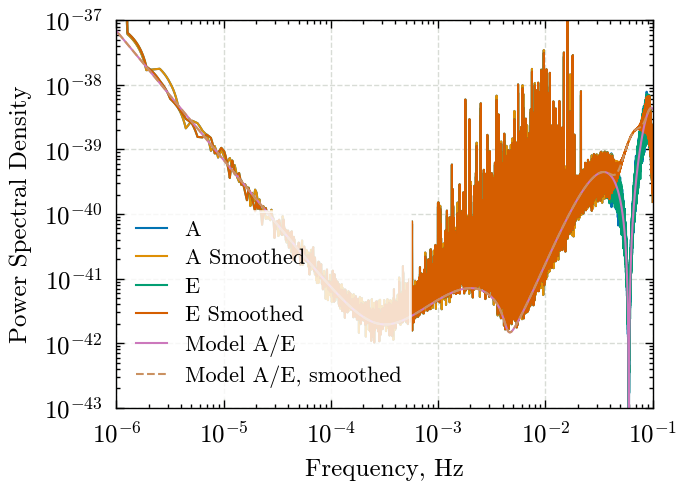

In [16]:

width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))

ax.loglog(
    A_psd.sample_frequencies,
    A_psd,
    label='A'
)
ax.loglog(
    A_psd.sample_frequencies,
    A_psd_smoothed,
    label='A Smoothed'
)
ax.loglog(
    E_psd.sample_frequencies,
    E_psd,
    label='E'
)
ax.loglog(
    E_psd.sample_frequencies,
    E_psd_smoothed,
    label='E Smoothed'
)
ax.loglog(
    sangria_model_freqs,
    sangria_model_ae_withgb,
    label='Model A/E'
)
ax.loglog(
    sangria_model_freqs,
    modelled_psd_smoothed,
    label='Model A/E, smoothed',
    linestyle='--'
)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='lower left')
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)